In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from models import *
import copy

from count_FM_function_v3 import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device("cpu")
print("device:", device)

device: cuda


# 1. read data

In [2]:
save_path = "pcx_141208-2_bank2_XC_bin001.npz"

# load
d = np.load(save_path, allow_pickle=True)
X_list = list(d["X_list"])
C_list = list(d["C_list"])
meta_list = list(d["meta_list"])
C_columns = list(d["C_columns"])

print("loaded:", len(X_list), len(C_list))
print("X[0].shape:", X_list[0].shape, "C[0].shape:", C_list[0].shape)
print("C_columns:", C_columns)

loaded: 480 480
X[0].shape: (200, 84) C[0].shape: (200, 5)
C_columns: ['t', 'rrr_mean', 'odor_present', 'odor_id', 'is_inhale']


In [3]:
X_list[0][0:10,0:10]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=object)

In [4]:
C_list[0][0:10,:]

array([[-0.495, 3.7955090488105383, 0.0, 0.0, 0.0],
       [-0.485, 1.8248321119158049, 0.0, 0.0, 0.0],
       [-0.475, -0.6450817834213126, 0.0, 0.0, 0.0],
       [-0.46499999999999997, -3.392807093287627, 0.0, 0.0, 0.0],
       [-0.45499999999999996, -7.097285627171937, 0.0, 0.0, 0.0],
       [-0.44499999999999995, -11.722603653287091, 0.0, 0.0, 0.0],
       [-0.43499999999999994, -16.489627641599146, 0.0, 0.0, 1.0],
       [-0.42499999999999993, -21.83216353535149, 0.0, 0.0, 1.0],
       [-0.4149999999999999, -27.773576648447715, 0.0, 0.0, 1.0],
       [-0.4049999999999999, -33.926428590310294, 0.0, 0.0, 1.0]],
      dtype=object)

In [5]:
C_list[-1][0:10]

array([[-0.495, 6.162707167307508, 0.0, 15.0, 0.0],
       [-0.485, 4.959961801523377, 0.0, 15.0, 0.0],
       [-0.475, 4.305044877913588, 0.0, 15.0, 0.0],
       [-0.46499999999999997, 3.134677594480672, 0.0, 15.0, 1.0],
       [-0.45499999999999996, 2.4009101141535667, 0.0, 15.0, 1.0],
       [-0.44499999999999995, 1.7237897596901348, 0.0, 15.0, 1.0],
       [-0.43499999999999994, 1.2068998268092854, 0.0, 15.0, 1.0],
       [-0.42499999999999993, 1.0654843594061731, 0.0, 15.0, 1.0],
       [-0.4149999999999999, 1.2095321381809299, 0.0, 15.0, 1.0],
       [-0.4049999999999999, 1.6325776279678395, 0.0, 15.0, 1.0]],
      dtype=object)

# 2. flatten data, split and loading

In [6]:
def _force_numeric(arr, dtype):
    a = np.asarray(arr)
    if a.dtype == object:
        return np.array(a, dtype=dtype)
    return a.astype(dtype, copy=False)

X_list = [_force_numeric(x, np.int64) for x in X_list]
C_list = [_force_numeric(c, np.float32) for c in C_list]

print("X_list[0].dtype:", X_list[0].dtype, "shape:", X_list[0].shape)
print("C_list[0].dtype:", C_list[0].dtype, "shape:", C_list[0].shape)

X_list[0].dtype: int64 shape: (200, 84)
C_list[0].dtype: float32 shape: (200, 5)


## 2.1 flatten

In [7]:
# optional: flattened view, only for row-level baseline experiments
X_flat = np.concatenate([x for x in X_list], axis=0)
C_flat = np.concatenate([c for c in C_list], axis=0)

mask_flat = np.isfinite(X_flat).all(axis=1) & np.isfinite(C_flat).all(axis=1)
X_flat = X_flat[mask_flat]
C_flat = C_flat[mask_flat]

X_flat = np.clip(X_flat, 0, None).astype(np.int64)
C_flat = C_flat.astype(np.float32)

print("X_flat shape:", X_flat.shape, "C_flat shape:", C_flat.shape)

X_flat shape: (96000, 84) C_flat shape: (96000, 5)


## 2.2 train-test split

In [8]:
ALL_COVARIATES = ['t', 'rrr_mean', 'odor_present', 'odor_id', 'is_inhale']
CONTINUOUS_COVARIATES = ['t', 'rrr_mean']
CATEGORICAL_COVARIATES = ['odor_present', 'odor_id', 'is_inhale']

In [9]:
SELECTED_COVARIATES = ['t', 'rrr_mean', 'odor_present', 'odor_id', 'is_inhale']
# SELECTED_COVARIATES = ['t', 'rrr_mean', 'odor_present', 'odor_id']
# SELECTED_COVARIATES = ['t', 'odor_present', 'odor_id', 'is_inhale']
# SELECTED_COVARIATES = ['rrr_mean', 'odor_present', 'odor_id', 'is_inhale']


col_idx = {name: i for i, name in enumerate(C_columns)}

selected_cont = [name for name in SELECTED_COVARIATES if name in CONTINUOUS_COVARIATES]
selected_cat  = [name for name in SELECTED_COVARIATES if name in CATEGORICAL_COVARIATES]

cont_idx = [col_idx[name] for name in selected_cont]
cat_idx  = [col_idx[name] for name in selected_cat]

# categorical cardinalities
cat_cardinality_map = {
    'odor_present': 2,
    'odor_id': 16,
    'is_inhale': 2,
}
cat_cardinalities = [cat_cardinality_map[name] for name in selected_cat]

print("selected_cont:", selected_cont)
print("selected_cat :", selected_cat)
print("cat_cardinalities:", cat_cardinalities)

selected_cont: ['t', 'rrr_mean']
selected_cat : ['odor_present', 'odor_id', 'is_inhale']
cat_cardinalities: [2, 16, 2]


In [10]:
# stratified trial-level split within each odor_id

p_train = 0.8
rng = np.random.RandomState(0)

odor_col = C_columns.index("odor_id")

# get one odor_id per trial
trial_odor_ids = []
for i in range(len(X_list)):
    Ci = np.asarray(C_list[i], dtype=np.float32)
    odor_i = int(np.rint(Ci[0, odor_col]))
    trial_odor_ids.append(odor_i)
trial_odor_ids = np.asarray(trial_odor_ids, dtype=np.int64)

unique_odors = np.unique(trial_odor_ids)

tr_trials = []
va_trials = []

for odor in unique_odors:
    idx_odor = np.where(trial_odor_ids == odor)[0]
    idx_odor = rng.permutation(idx_odor)

    n_odor = len(idx_odor)

    if n_odor == 1:
        # keep singleton odor in training so train covers all odor_id
        tr_i = idx_odor
        va_i = np.array([], dtype=np.int64)
    else:
        n_tr_i = int(np.floor(p_train * n_odor))
        n_tr_i = max(1, min(n_tr_i, n_odor - 1))   # ensure both train and val exist when possible

        tr_i = idx_odor[:n_tr_i]
        va_i = idx_odor[n_tr_i:]

    tr_trials.extend(tr_i.tolist())
    va_trials.extend(va_i.tolist())

tr_trials = np.array(sorted(tr_trials), dtype=np.int64)
va_trials = np.array(sorted(va_trials), dtype=np.int64)

Xtr_list = [np.clip(np.asarray(X_list[i]), 0, None).astype(np.int64) for i in tr_trials]
Xva_list = [np.clip(np.asarray(X_list[i]), 0, None).astype(np.int64) for i in va_trials]

Ctr_raw_list = [np.asarray(C_list[i], dtype=np.float32) for i in tr_trials]
Cva_raw_list = [np.asarray(C_list[i], dtype=np.float32) for i in va_trials]

# flatten within each split only
Xtr = np.concatenate(Xtr_list, axis=0)
Xva = np.concatenate(Xva_list, axis=0) if len(Xva_list) > 0 else np.zeros((0, Xtr.shape[1]), dtype=Xtr.dtype)

Ctr_raw = np.concatenate(Ctr_raw_list, axis=0)
Cva_raw = np.concatenate(Cva_raw_list, axis=0) if len(Cva_raw_list) > 0 else np.zeros((0, Ctr_raw.shape[1]), dtype=Ctr_raw.dtype)

# finite-row filtering within each split
mask_tr = np.isfinite(Xtr).all(axis=1) & np.isfinite(Ctr_raw).all(axis=1)
mask_va = np.isfinite(Xva).all(axis=1) & np.isfinite(Cva_raw).all(axis=1)

Xtr = Xtr[mask_tr]
Xva = Xva[mask_va]
Ctr_raw = Ctr_raw[mask_tr]
Cva_raw = Cva_raw[mask_va]

# select covariates
if len(cont_idx) > 0:
    Ctr_cont = Ctr_raw[:, cont_idx].astype(np.float32)
    Cva_cont = Cva_raw[:, cont_idx].astype(np.float32)
else:
    Ctr_cont = np.zeros((Ctr_raw.shape[0], 0), dtype=np.float32)
    Cva_cont = np.zeros((Cva_raw.shape[0], 0), dtype=np.float32)

if len(cat_idx) > 0:
    Ctr_cat = np.rint(Ctr_raw[:, cat_idx]).astype(np.int64)
    Cva_cat = np.rint(Cva_raw[:, cat_idx]).astype(np.int64)
else:
    Ctr_cat = np.zeros((Ctr_raw.shape[0], 0), dtype=np.int64)
    Cva_cat = np.zeros((Cva_raw.shape[0], 0), dtype=np.int64)

print("n_trials total:", len(X_list))
print("train trials:", len(tr_trials), "val trials:", len(va_trials))
print("train odor_ids:", np.unique(trial_odor_ids[tr_trials]))
print("val odor_ids:", np.unique(trial_odor_ids[va_trials]) if len(va_trials) > 0 else [])
print("Xtr shape:", Xtr.shape, "Xva shape:", Xva.shape)
print("Ctr_cont shape:", Ctr_cont.shape, "Cva_cont shape:", Cva_cont.shape)
print("Ctr_cat shape:", Ctr_cat.shape, "Cva_cat shape:", Cva_cat.shape)

# optional: trial counts by odor
for odor in unique_odors:
    n_tr_i = np.sum(trial_odor_ids[tr_trials] == odor)
    n_va_i = np.sum(trial_odor_ids[va_trials] == odor)
    print(f"odor {odor:2d}: train_trials={n_tr_i}, val_trials={n_va_i}")

Xtr_t = torch.from_numpy(Xtr).float()
Xva_t = torch.from_numpy(Xva).float()
Ctr_cont_t = torch.from_numpy(Ctr_cont).float()
Cva_cont_t = torch.from_numpy(Cva_cont).float()
Ctr_cat_t  = torch.from_numpy(Ctr_cat).long()
Cva_cat_t  = torch.from_numpy(Cva_cat).long()

train_ds = TensorDataset(Xtr_t, Ctr_cont_t, Ctr_cat_t)
val_ds   = TensorDataset(Xva_t, Cva_cont_t, Cva_cat_t)

batch_size = 1024
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

print("train rows:", len(train_ds), "val rows:", len(val_ds))

n_trials total: 480
train trials: 384 val trials: 96
train odor_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
val odor_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Xtr shape: (76800, 84) Xva shape: (19200, 84)
Ctr_cont shape: (76800, 2) Cva_cont shape: (19200, 2)
Ctr_cat shape: (76800, 3) Cva_cat shape: (19200, 3)
odor  0: train_trials=24, val_trials=6
odor  1: train_trials=24, val_trials=6
odor  2: train_trials=24, val_trials=6
odor  3: train_trials=24, val_trials=6
odor  4: train_trials=24, val_trials=6
odor  5: train_trials=24, val_trials=6
odor  6: train_trials=24, val_trials=6
odor  7: train_trials=24, val_trials=6
odor  8: train_trials=24, val_trials=6
odor  9: train_trials=24, val_trials=6
odor 10: train_trials=24, val_trials=6
odor 11: train_trials=24, val_trials=6
odor 12: train_trials=24, val_trials=6
odor 13: train_trials=24, val_trials=6
odor 14: train_trials=24, val_trials=6
odor 15: train_trials=24, val_trials=6
train rows: 76800 val rows: 19200


In [11]:
# # optional: flattened row-level split
# N = X_flat.shape[0]
# p_train = 0.8

# rng = np.random.RandomState(0)
# perm = rng.permutation(N)
# n_tr = int(p_train * N)
# tr_idx, va_idx = perm[:n_tr], perm[n_tr:]

# Xtr = X_flat[tr_idx]
# Xva = X_flat[va_idx]
# Ctr_raw = C_flat[tr_idx]
# Cva_raw = C_flat[va_idx]

# if len(cont_idx) > 0:
#     Ctr_cont = Ctr_raw[:, cont_idx].astype(np.float32)
#     Cva_cont = Cva_raw[:, cont_idx].astype(np.float32)
# else:
#     Ctr_cont = np.zeros((Ctr_raw.shape[0], 0), dtype=np.float32)
#     Cva_cont = np.zeros((Cva_raw.shape[0], 0), dtype=np.float32)

# if len(cat_idx) > 0:
#     Ctr_cat = np.rint(Ctr_raw[:, cat_idx]).astype(np.int64)
#     Cva_cat = np.rint(Cva_raw[:, cat_idx]).astype(np.int64)
# else:
#     Ctr_cat = np.zeros((Ctr_raw.shape[0], 0), dtype=np.int64)
#     Cva_cat = np.zeros((Cva_raw.shape[0], 0), dtype=np.int64)

# Xtr_t = torch.from_numpy(Xtr).float()
# Xva_t = torch.from_numpy(Xva).float()
# Ctr_cont_t = torch.from_numpy(Ctr_cont).float()
# Cva_cont_t = torch.from_numpy(Cva_cont).float()
# Ctr_cat_t  = torch.from_numpy(Ctr_cat).long()
# Cva_cat_t  = torch.from_numpy(Cva_cat).long()

# train_ds = TensorDataset(Xtr_t, Ctr_cont_t, Ctr_cat_t)
# val_ds   = TensorDataset(Xva_t, Cva_cont_t, Cva_cat_t)

# batch_size = 1024
# train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
# val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

# print("flattened split")
# print("train rows:", len(train_ds), "val rows:", len(val_ds))
# print("Ctr_cont shape:", Ctr_cont.shape, "Cva_cont shape:", Cva_cont.shape)
# print("Ctr_cat shape:", Ctr_cat.shape, "Cva_cat shape:", Cva_cat.shape)

# 3. Conditional model

We have 2 sets of covariates:
1. continuous: time, respiration wave form (rrr)
2. categorical: odor present index, odor index, inhale index

Seems inhale index helps in addition to rrr (derivative of rrr suggests inhale, but we don't use it)

In [12]:
class CondCountFMNet(nn.Module):
    def __init__(
        self,
        d,
        cont_dim,
        cat_cardinalities,
        emb_dim=16,
        cond_dim=32,
        d_model=64,
        depth=4,
        n_heads=4,
        mlp_ratio=4.0,
        dropout=0.0,
        chunk_size=16,
        log_cap=12.0,
        eps_out=1e-6,
        eps_time=1e-4,
    ):
        super().__init__()
        self.d = d
        self.cont_dim = cont_dim
        self.cat_cardinalities = list(cat_cardinalities)
        self.n_cat = len(self.cat_cardinalities)
        self.eps_out = eps_out
        self.eps_time = eps_time
        self.log_cap = log_cap

        self.cat_nulls = self.cat_cardinalities[:]   # null index = K for each cat with classes {0,...,K-1}

        if self.cont_dim > 0:
            self.cont_proj = nn.Linear(self.cont_dim, emb_dim)
            self.cont_null = nn.Parameter(torch.zeros(emb_dim))
        else:
            self.cont_proj = None
            self.cont_null = None

        self.cat_embs = nn.ModuleList([
            nn.Embedding(K + 1, emb_dim) for K in self.cat_cardinalities
        ])

        n_pieces = (1 if self.cont_dim > 0 else 0) + self.n_cat
        self.cond_fuse = nn.Sequential(
            nn.Linear(n_pieces * emb_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

        self.dim_total = d + cond_dim
        self.backbone = ChunkedAdaLNTransformer(
            dim=self.dim_total,
            out_dim=self.dim_total,
            time_varying=True,
            d_model=d_model,
            depth=depth,
            n_heads=n_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            chunk_size=chunk_size,
        )

        self.out_head = nn.Sequential(
            nn.SiLU(),
            nn.Linear(self.dim_total, 2 * d),
        )

    def encode_cond(self, c_cont, c_cat, is_uncond_mask=None):
        pieces = []

        if self.cont_dim > 0:
            e_cont = self.cont_proj(c_cont)
            if is_uncond_mask is not None and is_uncond_mask.any():
                e_cont = e_cont.clone()
                e_cont[is_uncond_mask] = self.cont_null.view(1, -1)
            pieces.append(e_cont)

        for j, emb in enumerate(self.cat_embs):
            pieces.append(emb(c_cat[:, j]))

        cond = torch.cat(pieces, dim=1)
        cond = self.cond_fuse(cond)
        return cond

    def forward(self, xt, t, c_cont, c_cat, is_uncond_mask=None):
        cond = self.encode_cond(c_cont, c_cat, is_uncond_mask=is_uncond_mask)
        x_in = torch.cat([xt, cond], dim=1)
        z = torch.cat([x_in, t], dim=1)

        h = self.backbone(z)
        out = self.out_head(h)

        lam_bar_raw, beta_bar_raw = out[:, :self.d], out[:, self.d:]
        lam_bar  = torch.exp(torch.clamp(lam_bar_raw,  max=self.log_cap)) + self.eps_out
        beta_bar = torch.exp(torch.clamp(beta_bar_raw, max=self.log_cap)) + self.eps_out

        denom = 1.0 - t + self.eps_time
        lam  = lam_bar  / denom
        beta = beta_bar / denom
        return lam, beta

In [13]:
class CondCountFMNet_MLP(nn.Module):
    def __init__(
        self,
        d,
        cont_dim,
        cat_cardinalities,
        emb_dim=16,
        hidden=128,
        depth=3,
        log_cap=12.0,
        eps_out=1e-6,
        eps_time=1e-4,
    ):
        super().__init__()
        self.d = d
        self.cont_dim = cont_dim
        self.cat_cardinalities = list(cat_cardinalities)
        self.n_cat = len(self.cat_cardinalities)
        self.eps_out = eps_out
        self.eps_time = eps_time
        self.log_cap = log_cap

        # null index = K for each categorical with classes {0,...,K-1}
        self.cat_nulls = self.cat_cardinalities[:]

        if self.cont_dim > 0:
            self.cont_proj = nn.Linear(self.cont_dim, emb_dim)
            self.cont_null = nn.Parameter(torch.zeros(emb_dim))
        else:
            self.cont_proj = None
            self.cont_null = None

        self.cat_embs = nn.ModuleList([
            nn.Embedding(K + 1, emb_dim) for K in self.cat_cardinalities
        ])

        n_pieces = (1 if self.cont_dim > 0 else 0) + self.n_cat
        in_dim = d + 1 + n_pieces * emb_dim   # xt + t + condition embeddings

        layers = []
        cur = in_dim
        for _ in range(depth):
            layers += [nn.Linear(cur, hidden), nn.SiLU()]
            cur = hidden
        layers += [nn.Linear(cur, 2 * d)]
        self.mlp = nn.Sequential(*layers)

    def encode_cond(self, c_cont, c_cat, is_uncond_mask=None):
        pieces = []

        if self.cont_dim > 0:
            e_cont = self.cont_proj(c_cont)
            if is_uncond_mask is not None and is_uncond_mask.any():
                e_cont = e_cont.clone()
                e_cont[is_uncond_mask] = self.cont_null.view(1, -1)
            pieces.append(e_cont)

        for j, emb in enumerate(self.cat_embs):
            pieces.append(emb(c_cat[:, j]))

        return torch.cat(pieces, dim=1)

    def forward(self, xt, t, c_cont, c_cat, is_uncond_mask=None):
        cond = self.encode_cond(c_cont, c_cat, is_uncond_mask=is_uncond_mask)
        h = torch.cat([xt, t, cond], dim=1)
        out = self.mlp(h)

        lam_bar_raw, beta_bar_raw = out[:, :self.d], out[:, self.d:]

        lam_bar = torch.exp(torch.clamp(lam_bar_raw, max=self.log_cap)) + self.eps_out
        beta_bar = torch.exp(torch.clamp(beta_bar_raw, max=self.log_cap)) + self.eps_out

        denom = 1.0 - t + self.eps_time
        lam = lam_bar / denom
        beta = beta_bar / denom
        return lam, beta

    def forward_uncond(self, xt, t):
        B = xt.shape[0]

        if self.cont_dim > 0:
            c_cont = torch.zeros((B, self.cont_dim), device=xt.device, dtype=torch.float32)
        else:
            c_cont = torch.zeros((B, 0), device=xt.device, dtype=torch.float32)

        if self.n_cat > 0:
            c_cat = torch.empty((B, self.n_cat), device=xt.device, dtype=torch.long)
            for j, null_idx in enumerate(self.cat_nulls):
                c_cat[:, j] = null_idx
        else:
            c_cat = torch.zeros((B, 0), device=xt.device, dtype=torch.long)

        is_uncond = torch.ones((B,), device=xt.device, dtype=torch.bool)
        return self.forward(xt, t, c_cont, c_cat, is_uncond_mask=is_uncond)

# 4. Training Loop
conditional count-FM + CFG dropout training

In [14]:
def eval_one_epoch(net, loader, eps_t=1e-4,
                   eps_log=1e-8, loss_mode="poisson",
                   C_max=None, margin=2,
                   x0_mode="uniform", x0_poisson_rate=1.0):
    net.eval()
    losses = []
    with torch.no_grad():
        for x1, ccont, ccat in loader:
            x1 = x1.to(device)
            ccont = ccont.to(device)
            ccat = ccat.to(device)

            B, d = x1.shape
            if C_max is None:
                C_max_local = int(x1.max().item() + margin)
            else:
                C_max_local = C_max

            # 
            if x0_mode == "uniform":
                if C_max is None:
                    C_max_local = int(x1.max().item() + margin)
                else:
                    C_max_local = int(C_max)

                x0 = torch.randint(0, C_max_local + 1, size=x1.shape,
                                   device=device, dtype=torch.long).to(x1.dtype)
            
            elif x0_mode == "poisson":
                x0 = torch.poisson(
                    torch.full_like(x1, float(x0_poisson_rate),
                                    dtype=torch.float32)
                ).to(x1.dtype)
            
            else:
                raise ValueError(f"Unknown x0_mode: {x0_mode}")

            # time and bridge
            t = torch.rand(B, 1, device=device) * (1.0 - 2.0 * eps_t) + eps_t

            # u = torch.rand(B, 1, device=device)
            # gamma_t = 2.0   # try 2.0 first, then 1.5 or 3.0
            # z = 1.0 - (1.0 - u) ** gamma_t   # pushes mass toward 1 when gamma_t > 1
            # t = eps_t + (1.0 - 2.0 * eps_t) * z

            # one_minus_z = (1.0 - z).clamp_min(1e-8)
            # w = gamma_t * one_minus_z ** (1.0 - 1.0 / gamma_t)  # shape [B,1]
            # w = (w / w.mean()).view(-1)
            
            xt = sample_xt(x0, x1, t)
            rates_star, idx_0 = sample_rt(xt, x1, t, eps_t)

            lam, beta = net(xt, t, ccont, ccat, is_uncond_mask=None)
            mu = (xt * beta) * (1.0 - idx_0)
            rates_theta = torch.cat([lam, mu], dim=1)
            
            loss = model_loss(loss_mode, rates_theta, rates_star, eps_log)
            
            # if loss_mode == "l2":
            #     per = ((rates_theta - rates_star) ** 2).sum(dim=1)  # [B]
            # else:
            #     u_star = rates_star
            #     v_th   = rates_theta
            #     per = (v_th - u_star * torch.log(v_th + eps_log)).sum(dim=1)  # [B]
            # loss = (w * per).mean()
            
            losses.append(loss.item())

    return float(np.mean(losses)) if len(losses) else np.nan


def _make_epoch_train_monitor_loaders(train_loader, monitor_fraction=0.1, seed=0):
    ds = train_loader.dataset
    tensors = ds.tensors
    N = len(ds)

    n_monitor = int(round(monitor_fraction * N))
    n_monitor = max(1, min(n_monitor, N - 1))

    g = torch.Generator()
    g.manual_seed(int(seed))
    perm = torch.randperm(N, generator=g)

    monitor_idx = perm[:n_monitor]
    train_idx = perm[n_monitor:]

    train_epoch_ds = TensorDataset(*(t[train_idx] for t in tensors))
    monitor_epoch_ds = TensorDataset(*(t[monitor_idx] for t in tensors))

    batch_size = train_loader.batch_size
    train_epoch_loader = DataLoader(
        train_epoch_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=train_loader.drop_last,
    )
    monitor_epoch_loader = DataLoader(
        monitor_epoch_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )
    return train_epoch_loader, monitor_epoch_loader


def train_cond_countfm_cfg(
    net,
    opt,
    train_loader,
    val_loader=None,                 # if None, use rotating monitor split inside training
    num_epochs=50,
    x0_mode="uniform",
    x0_poisson_rate=1.0,
    C_max=None,
    margin=2,
    eps_t=1e-4,
    eps_log=1e-8,
    loss_mode="poisson",
    p_uncond=0.1,
    monitor_fraction=0.1,           # only used if val_loader is None
    eval_every=5,
    patience=30,
    min_delta=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=8,
    min_lr=1e-5,
    split_seed=0,
):
    if C_max is None:
        all_x = train_loader.dataset.tensors[0]
        C_max = int(all_x.max().item() + margin)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="min",
        factor=scheduler_factor,
        patience=scheduler_patience,
        min_lr=min_lr,
    )

    best_metric = np.inf
    best_state = copy.deepcopy(net.state_dict())
    best_epoch = -1
    bad_count = 0
    history = []

    print(
        "C_max:", C_max,
        "p_uncond:", p_uncond,
        "x0_mode:", x0_mode,
        "monitor_fraction:", monitor_fraction if val_loader is None else "fixed_val_loader",
    )

    for ep in range(num_epochs):
        if val_loader is None:
            train_epoch_loader, monitor_loader = _make_epoch_train_monitor_loaders(
                train_loader,
                monitor_fraction=monitor_fraction,
                seed=split_seed + ep,
            )
        else:
            train_epoch_loader = train_loader
            monitor_loader = val_loader

        net.train()
        train_losses = []

        for x1, ccont, ccat in train_epoch_loader:
            x1 = x1.to(device)
            ccont = ccont.to(device)
            ccat = ccat.to(device)

            B, d = x1.shape

            if x0_mode == "uniform":
                x0 = torch.randint(
                    0, C_max + 1,
                    size=x1.shape,
                    device=device,
                    dtype=torch.long,
                ).to(x1.dtype)

            elif x0_mode == "poisson":
                x0 = torch.poisson(
                    torch.full_like(x1, float(x0_poisson_rate), dtype=torch.float32)
                ).to(x1.dtype)

            else:
                raise ValueError("x0_mode must be 'uniform' or 'poisson'")

            t = torch.rand(B, 1, device=device) * (1.0 - 2.0 * eps_t) + eps_t
            xt = sample_xt(x0, x1, t)
            rates_star, idx_0 = sample_rt(xt, x1, t, eps_t)

            drop = (torch.rand(B, device=device) < p_uncond)
            if drop.any():
                ccont = ccont.clone()
                ccat = ccat.clone()
                for j, null_idx in enumerate(net.cat_nulls):
                    ccat[drop, j] = null_idx

            lam, beta = net(xt, t, ccont, ccat, is_uncond_mask=drop)
            mu = (xt * beta) * (1.0 - idx_0)
            rates_theta = torch.cat([lam, mu], dim=1)

            loss = model_loss(loss_mode, rates_theta, rates_star, eps_log)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses)) if len(train_losses) else np.nan

        if (ep % eval_every == 0) or (ep == num_epochs - 1):
            monitor_loss = eval_one_epoch(
                net,
                monitor_loader,
                eps_t=eps_t,
                eps_log=eps_log,
                loss_mode=loss_mode,
                C_max=C_max,
                x0_mode=x0_mode,
                x0_poisson_rate=x0_poisson_rate,
            )

            scheduler.step(monitor_loss)
            lr_now = opt.param_groups[0]["lr"]

            history.append({
                "epoch": ep,
                "train_loss": train_loss,
                "monitor_loss": monitor_loss,
                "lr": lr_now,
            })

            improved = monitor_loss < (best_metric - min_delta)
            if improved:
                best_metric = monitor_loss
                best_state = copy.deepcopy(net.state_dict())
                best_epoch = ep
                bad_count = 0
            else:
                bad_count += 1

            print(
                f"[ep {ep}] train_loss={train_loss:.6f}  "
                f"monitor_loss={monitor_loss:.6f}  lr={lr_now:.2e}  "
                f"best={best_metric:.6f} @ {best_epoch}"
            )

            if bad_count >= patience:
                print(f"Early stop at ep {ep}. Restore best epoch {best_epoch}.")
                break

    net.load_state_dict(best_state)
    return net, C_max, history

## begin to train

In [15]:
x0_poisson_rate = float(Xtr.mean())
# x0_poisson_rate = 1.0

X0_CFG = dict(
    x0_mode="poisson",          # "uniform"/ "poisson"
    x0_poisson_rate=x0_poisson_rate,
)

print("x0_poisson_rate =", X0_CFG["x0_poisson_rate"])

x0_poisson_rate = 0.01494109623015873


In [16]:
d = Xtr_t.shape[1]
eps_t = 1e-4
model_type = "mlp" # mlp/ transformer

if model_type == "transformer":

    MODEL_KWARGS = dict(
        d=d,
        cont_dim=Ctr_cont_t.shape[1],
        cat_cardinalities=cat_cardinalities,
        emb_dim=16,
        cond_dim=32,
        d_model=64,
        depth=4,
        n_heads=4,
        mlp_ratio=4.0,
        dropout=0.05,
        chunk_size=16,
        log_cap=5.0,
        eps_time=eps_t,
    )
    net = CondCountFMNet(**MODEL_KWARGS).to(device)    

else:

    MODEL_MLP_KWARGS = dict(
        d=d,
        cont_dim=Ctr_cont_t.shape[1],
        cat_cardinalities=cat_cardinalities,
        emb_dim=16,
        hidden=128,
        depth=3,
        log_cap=5.0,
        eps_time=eps_t,
    )
    
    net = CondCountFMNet_MLP(**MODEL_MLP_KWARGS).to(device)

In [17]:
lr = 1e-3
opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)

# net, C_max, hist = train_cond_countfm_cfg(
#     net=net,
#     opt=opt,
#     train_loader=train_loader,
#     val_loader=None,                 # use rotating monitor split inside training
#     num_epochs=1000,
#     x0_mode=X0_CFG["x0_mode"],
#     x0_poisson_rate=X0_CFG["x0_poisson_rate"],
#     eps_t=eps_t,
#     C_max=None,
#     p_uncond=0.1,
#     monitor_fraction=0.1,
#     eval_every=5,
#     patience=30,
#     min_delta=1e-4,
#     scheduler_factor=0.5,
#     scheduler_patience=8,
#     min_lr=1e-5,
#     split_seed=0,
# )

In [18]:
# # save_path = "cond_countfm_cfg_ckpt_all_poi_meanRate_trial_level_split.pt"
# save_path = "cond_countfm_cfg_ckpt_all_poi_meanRate_trial_level_split_mlp.pt"

# if model_type == "transformer":

#     ckpt = {
#         "state_dict": net.state_dict(),
#         "C_max": C_max,
#         "model_kwargs": MODEL_KWARGS,
#         "x0_mode": X0_CFG["x0_mode"],
#         "x0_poisson_rate": X0_CFG["x0_poisson_rate"],
#         "optimizer_state_dict": opt.state_dict(),
#     }
    
# else:
    
#     ckpt = {
#         "state_dict": net.state_dict(),
#         "C_max": C_max,
#         "model_kwargs": MODEL_MLP_KWARGS,
#         "x0_mode": X0_CFG["x0_mode"],
#         "x0_poisson_rate": X0_CFG["x0_poisson_rate"],
#         "optimizer_state_dict": opt.state_dict(),
#     }

# torch.save(ckpt, save_path)
# print("saved to", save_path)

In [19]:
# save_path = "cond_countfm_cfg_ckpt_all_poi_meanRate_trial_level_split.pt"
save_path = "cond_countfm_cfg_ckpt_all_poi_meanRate_trial_level_split_mlp.pt"

ckpt = torch.load(save_path, map_location="cpu")


if model_type == "transformer":
    net = CondCountFMNet(**ckpt["model_kwargs"])
else:
    net = CondCountFMNet_MLP(**ckpt["model_kwargs"])


net.load_state_dict(ckpt["state_dict"])
C_max = ckpt["C_max"]

x0_mode = ckpt.get("x0_mode", "uniform")
x0_poisson_rate = ckpt.get("x0_poisson_rate", 1.0)

net = net.to(device).eval()
print("loaded. C_max =", C_max)
print("x0_mode =", x0_mode, "x0_poisson_rate =", x0_poisson_rate)
print(model_type)

loaded. C_max = 5
x0_mode = poisson x0_poisson_rate = 0.01494109623015873
mlp


# 5. CFG generation

In [20]:
@torch.no_grad()
def sample_euler_cfg_condcountfm(
    net,
    n_step,
    x0,
    ccont,
    ccat,
    guidance_scale=1.0,
    eps_t=1e-4,
    eps_log=1e-8,
):
    net.eval()
    xt = x0.to(device=device, dtype=torch.float32).clone()
    N, d = xt.shape

    ccont = ccont.to(device=device, dtype=torch.float32)
    ccat  = ccat.to(device=device, dtype=torch.long)

    t = torch.full((N, 1), eps_t, device=device, dtype=torch.float32)
    Delta = torch.tensor((1.0 - 2.0 * eps_t) / float(n_step), device=device, dtype=torch.float32)

    ccont_u = torch.zeros((N, net.cont_dim), device=device, dtype=torch.float32)
    ccat_u = ccat.clone()
    for j, null_idx in enumerate(net.cat_nulls):
        ccat_u[:, j] = null_idx
    uncond_mask = torch.ones((N,), device=device, dtype=torch.bool)

    for _ in range(n_step):
        lam_c, beta_c = net(xt, t, ccont,  ccat,  is_uncond_mask=None)
        lam_u, beta_u = net(xt, t, ccont_u, ccat_u, is_uncond_mask=uncond_mask)

        lam  = lam_u  + guidance_scale * (lam_c  - lam_u)
        beta = beta_u + guidance_scale * (beta_c - beta_u)
        lam  = F.relu(lam)  + 1e-8
        beta = F.relu(beta) + 1e-8

        idx_0 = (xt <= 0).to(torch.float32)
        mu = (xt * beta) * (1.0 - idx_0)

        r = lam + mu
        p_none  = torch.exp(-r * Delta)
        p_jump  = 1.0 - p_none
        p_birth = p_jump * (lam / (r + eps_log))
        p_death = p_jump * (mu  / (r + eps_log))

        probs3 = torch.stack([p_none, p_birth, p_death], dim=-1)
        probs3_flat = probs3.reshape(-1, 3)
        probs3_flat = probs3_flat / probs3_flat.sum(dim=1, keepdim=True)

        choice = torch.multinomial(probs3_flat, 1).view(N, d)
        adj = (choice == 1).to(torch.float32) - (choice == 2).to(torch.float32)
        xt = torch.clamp(xt + adj, min=0.0)

        t = torch.minimum(t + Delta, torch.full_like(t, 1.0 - eps_t))

    return xt.to(torch.long)

# Plotting

In [21]:
CONTINUOUS_COVARIATES = ['t', 'rrr_mean']
CATEGORICAL_COVARIATES = ['odor_present', 'odor_id', 'is_inhale']
col_idx = {name: i for i, name in enumerate(C_columns)}

guidance_scales_gen = [0.0, 1.0, 2.0]
n_step_gen = 1000
seed_gen = 123

def _build_covariates_from_raw(C_raw, selected_covariates):
    selected_cont = [name for name in selected_covariates if name in CONTINUOUS_COVARIATES]
    selected_cat  = [name for name in selected_covariates if name in CATEGORICAL_COVARIATES]

    cont_idx_local = [col_idx[name] for name in selected_cont]
    cat_idx_local  = [col_idx[name] for name in selected_cat]

    if len(cont_idx_local) > 0:
        C_cont = C_raw[:, cont_idx_local].astype(np.float32)
    else:
        C_cont = np.zeros((C_raw.shape[0], 0), dtype=np.float32)

    if len(cat_idx_local) > 0:
        C_cat = np.rint(C_raw[:, cat_idx_local]).astype(np.int64)
    else:
        C_cat = np.zeros((C_raw.shape[0], 0), dtype=np.int64)

    return torch.from_numpy(C_cont).float(), torch.from_numpy(C_cat).long()

def _make_x0(shape, seed):
    g = torch.Generator(device="cpu")
    g.manual_seed(int(seed))

    if X0_CFG["x0_mode"] == "uniform":
        return torch.randint(
            low=0,
            high=C_max + 1,
            size=shape,
            generator=g,
            device=torch.device("cpu"),
            dtype=torch.long,
        ).float()

    elif X0_CFG["x0_mode"] == "poisson":
        return torch.poisson(
            torch.full(
                shape,
                float(X0_CFG.get("x0_poisson_rate", 1.0)),
                device=torch.device("cpu"),
                dtype=torch.float32,
            ),
            generator=g,
        )

    else:
        raise ValueError(f'Unknown x0_mode: {X0_CFG["x0_mode"]}')

def _centers_to_edges(x):
    x = np.asarray(x, dtype=float)
    if x.ndim != 1 or len(x) < 2:
        raise ValueError("x must be a 1D array with at least 2 points")
    mids = 0.5 * (x[:-1] + x[1:])
    left = x[0] - 0.5 * (x[1] - x[0])
    right = x[-1] + 0.5 * (x[-1] - x[-2])
    return np.concatenate([[left], mids, [right]])

def _plot_heatmap(ax, X, t_vals, title, vmin=None, vmax=None):
    t_edges = _centers_to_edges(t_vals)
    y_edges = np.arange(X.shape[1] + 1) - 0.5

    im = ax.pcolormesh(
        t_edges,
        y_edges,
        X.T,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title, pad=6)
    ax.set_ylabel("neuron")
    ax.axvline(0.0, linestyle="--", linewidth=1.2, color="orange")
    return im

def _bin_conditional_mean(x, y, nbins=20):
    edges = np.quantile(x, np.linspace(0, 1, nbins + 1))
    edges[0] -= 1e-8
    edges[-1] += 1e-8

    mids = 0.5 * (edges[:-1] + edges[1:])
    out = np.full(nbins, np.nan, dtype=float)

    for i in range(nbins):
        if i < nbins - 1:
            m = (x >= edges[i]) & (x < edges[i + 1])
        else:
            m = (x >= edges[i]) & (x <= edges[i + 1])
        if np.any(m):
            out[i] = y[m].mean()

    return mids, out

def _group_conditional_mean(g, y):
    levels = np.unique(g)
    means = np.array([y[g == lv].mean() for lv in levels], dtype=float)
    return levels, means

In [22]:
# choose which trial set to generate once
trial_ids_gen = np.array(va_trials, dtype=int)
# trial_ids_gen = np.array(tr_trials, dtype=int)

model_gen = net.to(device).eval()

odor_col = C_columns.index("odor_id")
t_col = C_columns.index("t")

X_trials = [np.asarray(X_list[idx], dtype=np.int64) for idx in trial_ids_gen]
C_trials = [np.asarray(C_list[idx], dtype=np.float32) for idx in trial_ids_gen]

T0 = X_trials[0].shape[0]
d0 = X_trials[0].shape[1]
for k in range(len(X_trials)):
    assert X_trials[k].shape == (T0, d0)
    assert C_trials[k].shape[0] == T0

X_true_all = np.concatenate(X_trials, axis=0)
C_all = np.concatenate(C_trials, axis=0)
row_odor_all = np.rint(C_all[:, odor_col]).astype(np.int64)

# row bounds for each trial
trial_row_bounds = {}
start = 0
for idx, Xi, Ci in zip(trial_ids_gen, X_trials, C_trials):
    stop = start + Xi.shape[0]
    trial_row_bounds[int(idx)] = (start, stop)
    start = stop

# per-trial metadata
trial_odor_map = {}
trial_t_map = {}
for idx, Ci in zip(trial_ids_gen, C_trials):
    trial_odor_map[int(idx)] = int(np.rint(Ci[0, odor_col]))
    trial_t_map[int(idx)] = np.asarray(Ci[:, t_col], dtype=float)

ccont_all, ccat_all = _build_covariates_from_raw(C_all, SELECTED_COVARIATES)
x0_all = _make_x0(X_true_all.shape, seed_gen)

X_gen_all = {}
with torch.no_grad():
    for gs in guidance_scales_gen:
        X_gen_all[gs] = sample_euler_cfg_condcountfm(
            model_gen,
            n_step=n_step_gen,
            x0=x0_all.clone(),
            ccont=ccont_all,
            ccat=ccat_all,
            guidance_scale=gs,
        ).cpu().numpy().astype(np.int64)

GEN_CACHE = dict(
    trial_ids=np.array(trial_ids_gen, dtype=int),
    X_true_all=X_true_all,
    C_all=C_all,
    row_odor_all=row_odor_all,
    X_gen_all=X_gen_all,
    trial_row_bounds=trial_row_bounds,
    trial_odor_map=trial_odor_map,
    trial_t_map=trial_t_map,
    T=T0,
    d=d0,
    guidance_scales=list(guidance_scales_gen),
)

print("generated once.")
print("X_true_all shape:", GEN_CACHE["X_true_all"].shape)
for gs in GEN_CACHE["guidance_scales"]:
    print(f'X_gen_all[{gs}] shape:', GEN_CACHE["X_gen_all"][gs].shape)
print("n trials:", len(GEN_CACHE["trial_ids"]))

generated once.
X_true_all shape: (19200, 84)
X_gen_all[0.0] shape: (19200, 84)
X_gen_all[1.0] shape: (19200, 84)
X_gen_all[2.0] shape: (19200, 84)
n trials: 96


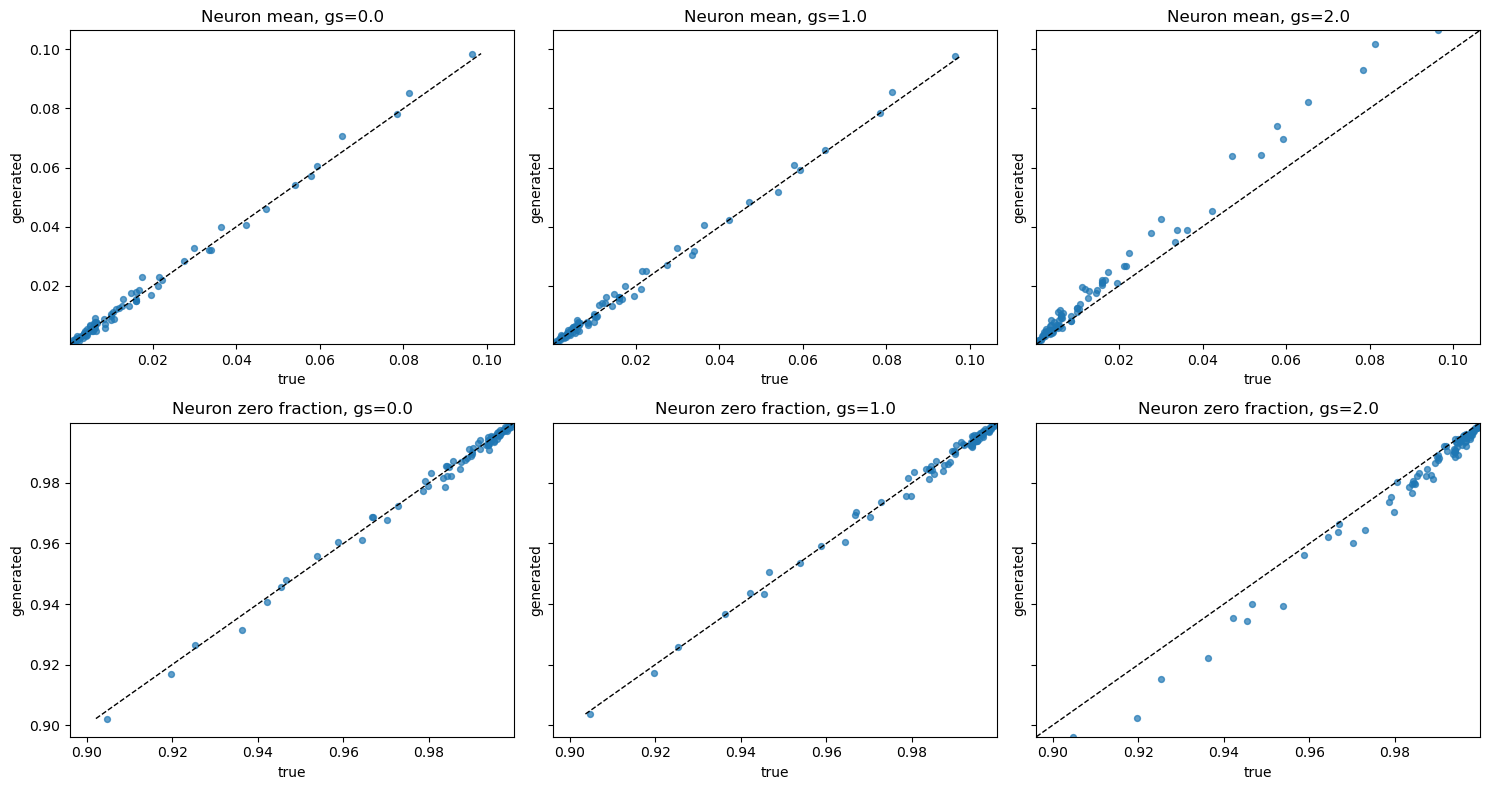

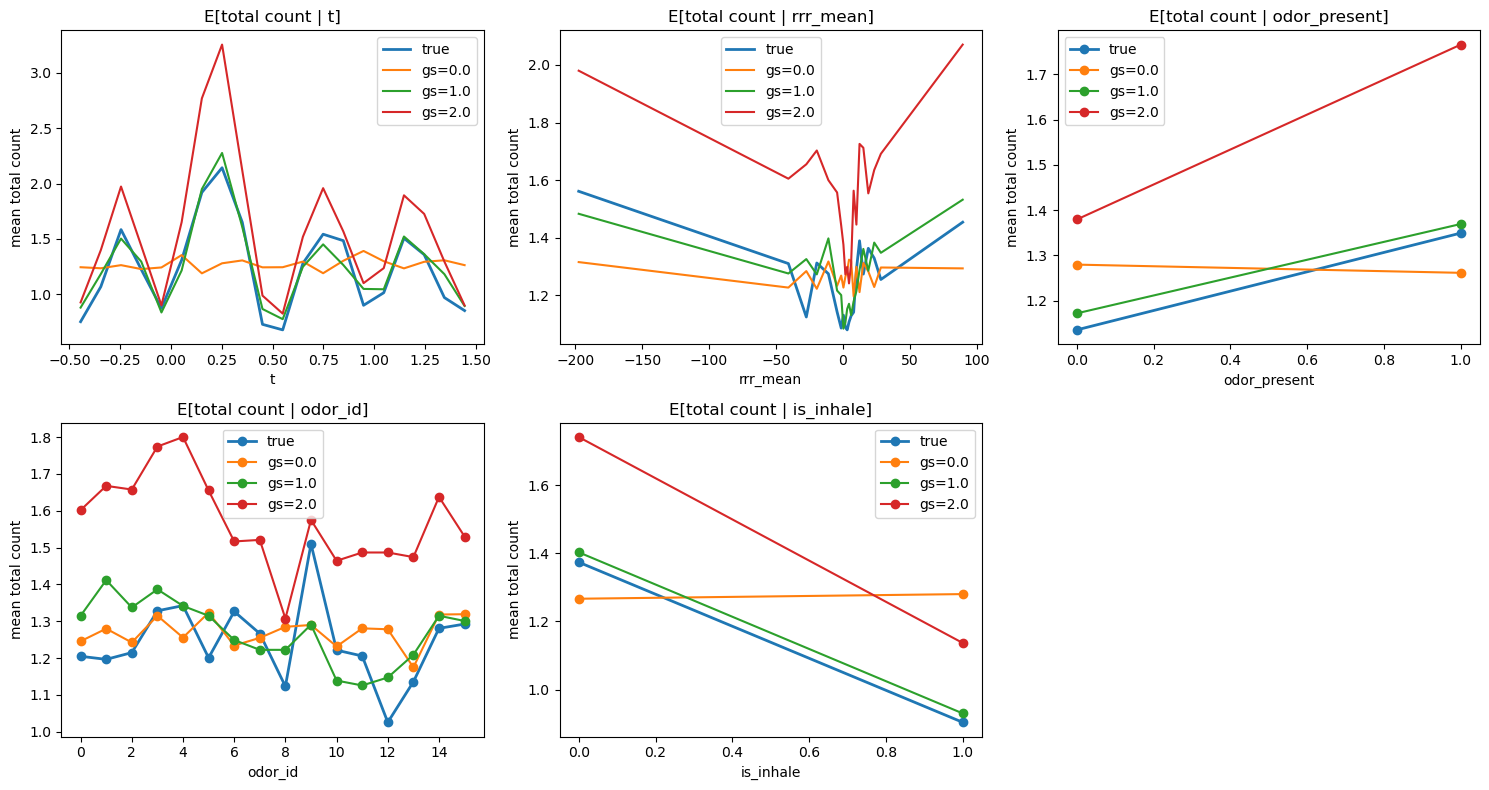

In [23]:
X_true_all = GEN_CACHE["X_true_all"]
X_gen_all = GEN_CACHE["X_gen_all"]
C_all = GEN_CACHE["C_all"]
guidance_scales = GEN_CACHE["guidance_scales"]

# 1. marginal generation quality for each neuron
fig, axes = plt.subplots(2, len(guidance_scales), figsize=(5 * len(guidance_scales), 8), sharex='row', sharey='row')

true_mean = X_true_all.mean(axis=0)
true_zero = (X_true_all == 0).mean(axis=0)

for k, gs in enumerate(guidance_scales):
    gen_mean = X_gen_all[gs].mean(axis=0)
    gen_zero = (X_gen_all[gs] == 0).mean(axis=0)

    ax = axes[0, k]
    ax.scatter(true_mean, gen_mean, alpha=0.7, s=18)
    lo = min(true_mean.min(), gen_mean.min())
    hi = max(true_mean.max(), gen_mean.max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1)
    ax.set_title(f"Neuron mean, gs={gs}")
    ax.set_xlabel("true")
    ax.set_ylabel("generated")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax = axes[1, k]
    ax.scatter(true_zero, gen_zero, alpha=0.7, s=18)
    lo = min(true_zero.min(), gen_zero.min())
    hi = max(true_zero.max(), gen_zero.max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1)
    ax.set_title(f"Neuron zero fraction, gs={gs}")
    ax.set_xlabel("true")
    ax.set_ylabel("generated")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

plt.tight_layout()
plt.show()

# 2. conditional generation quality given covariates
total_true = X_true_all.sum(axis=1)
total_gen = {gs: X_gen_all[gs].sum(axis=1) for gs in guidance_scales}

cov_t = np.asarray(C_all[:, C_columns.index("t")], dtype=float)
cov_rrr = np.asarray(C_all[:, C_columns.index("rrr_mean")], dtype=float)
cov_odor_on = np.rint(C_all[:, C_columns.index("odor_present")]).astype(int)
cov_odor_id = np.rint(C_all[:, C_columns.index("odor_id")]).astype(int)
cov_inhale = np.rint(C_all[:, C_columns.index("is_inhale")]).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

x_mid, y_true = _bin_conditional_mean(cov_t, total_true, nbins=20)
ax = axes[0, 0]
ax.plot(x_mid, y_true, linewidth=2, label="true")
for gs in guidance_scales:
    _, y_gen = _bin_conditional_mean(cov_t, total_gen[gs], nbins=20)
    ax.plot(x_mid, y_gen, label=f"gs={gs}")
ax.set_title("E[total count | t]")
ax.set_xlabel("t")
ax.set_ylabel("mean total count")
ax.legend()

x_mid, y_true = _bin_conditional_mean(cov_rrr, total_true, nbins=20)
ax = axes[0, 1]
ax.plot(x_mid, y_true, linewidth=2, label="true")
for gs in guidance_scales:
    _, y_gen = _bin_conditional_mean(cov_rrr, total_gen[gs], nbins=20)
    ax.plot(x_mid, y_gen, label=f"gs={gs}")
ax.set_title("E[total count | rrr_mean]")
ax.set_xlabel("rrr_mean")
ax.set_ylabel("mean total count")
ax.legend()

levels, y_true = _group_conditional_mean(cov_odor_on, total_true)
ax = axes[0, 2]
ax.plot(levels, y_true, marker="o", linewidth=2, label="true")
for gs in guidance_scales:
    _, y_gen = _group_conditional_mean(cov_odor_on, total_gen[gs])
    ax.plot(levels, y_gen, marker="o", label=f"gs={gs}")
ax.set_title("E[total count | odor_present]")
ax.set_xlabel("odor_present")
ax.set_ylabel("mean total count")
ax.legend()

levels, y_true = _group_conditional_mean(cov_odor_id, total_true)
ax = axes[1, 0]
ax.plot(levels, y_true, marker="o", linewidth=2, label="true")
for gs in guidance_scales:
    _, y_gen = _group_conditional_mean(cov_odor_id, total_gen[gs])
    ax.plot(levels, y_gen, marker="o", label=f"gs={gs}")
ax.set_title("E[total count | odor_id]")
ax.set_xlabel("odor_id")
ax.set_ylabel("mean total count")
ax.legend()

levels, y_true = _group_conditional_mean(cov_inhale, total_true)
ax = axes[1, 1]
ax.plot(levels, y_true, marker="o", linewidth=2, label="true")
for gs in guidance_scales:
    _, y_gen = _group_conditional_mean(cov_inhale, total_gen[gs])
    ax.plot(levels, y_gen, marker="o", label=f"gs={gs}")
ax.set_title("E[total count | is_inhale]")
ax.set_xlabel("is_inhale")
ax.set_ylabel("mean total count")
ax.legend()

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

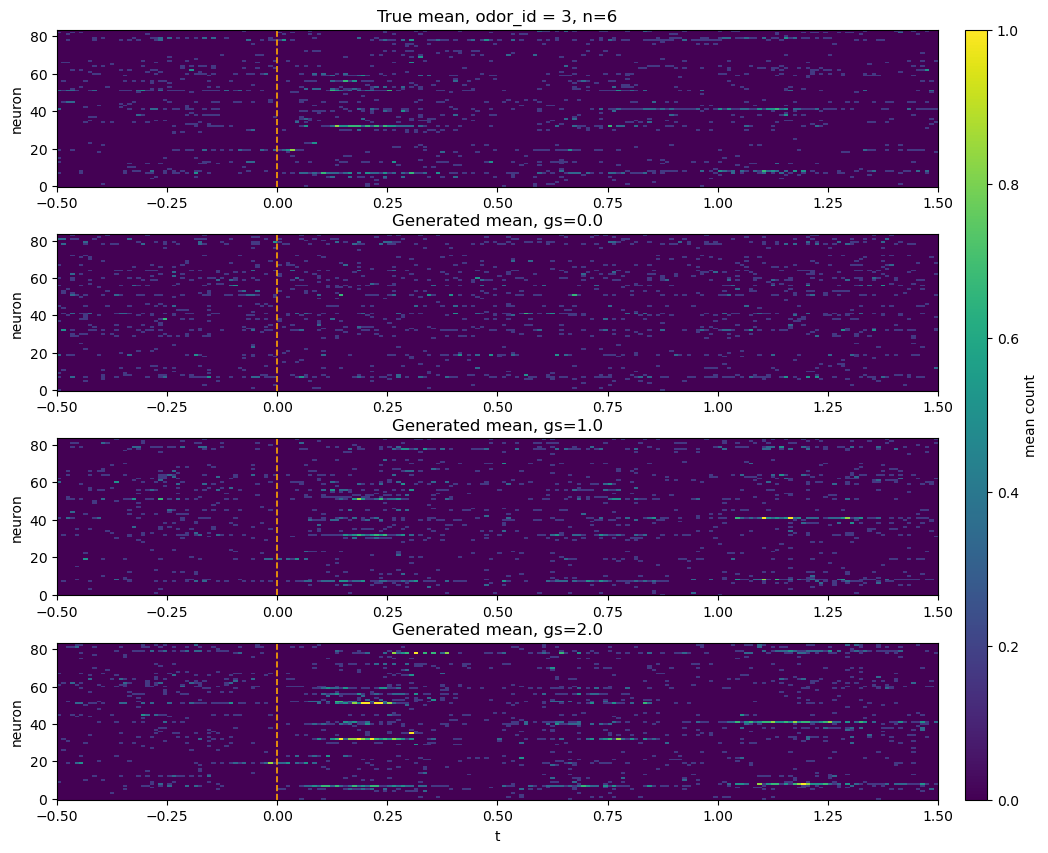

In [24]:
use_same_odor_only = True
odor_id_use = 3

trial_ids_all = GEN_CACHE["trial_ids"]

if use_same_odor_only:
    trial_ids_fig2 = np.array(
        [idx for idx in trial_ids_all if GEN_CACHE["trial_odor_map"][int(idx)] == odor_id_use],
        dtype=int,
    )
else:
    trial_ids_fig2 = trial_ids_all.copy()

if len(trial_ids_fig2) == 0:
    raise ValueError("No trials selected.")

X_true_trials = []
X_gen_trials = {gs: [] for gs in GEN_CACHE["guidance_scales"]}

for idx in trial_ids_fig2:
    start, stop = GEN_CACHE["trial_row_bounds"][int(idx)]
    X_true_trials.append(GEN_CACHE["X_true_all"][start:stop])
    for gs in GEN_CACHE["guidance_scales"]:
        X_gen_trials[gs].append(GEN_CACHE["X_gen_all"][gs][start:stop])

X_true_mean = np.stack(X_true_trials, axis=0).mean(axis=0)
X_gen_mean = {gs: np.stack(X_gen_trials[gs], axis=0).mean(axis=0) for gs in GEN_CACHE["guidance_scales"]}

t_fig2 = GEN_CACHE["trial_t_map"][int(trial_ids_fig2[0])]

all_vals = [X_true_mean.ravel()] + [X_gen_mean[gs].ravel() for gs in GEN_CACHE["guidance_scales"]]
all_vals = np.concatenate(all_vals)
vmin = 0
vmax = max(1, np.percentile(all_vals, 99.5))

fig = plt.figure(figsize=(12, 10))
gspec = fig.add_gridspec(
    nrows=4,
    ncols=2,
    width_ratios=[40, 1],
    height_ratios=[1, 1, 1, 1],
    wspace=0.06,
    hspace=0.30,
)

ax0 = fig.add_subplot(gspec[0, 0])
ax1 = fig.add_subplot(gspec[1, 0], sharex=ax0, sharey=ax0)
ax2 = fig.add_subplot(gspec[2, 0], sharex=ax0, sharey=ax0)
ax3 = fig.add_subplot(gspec[3, 0], sharex=ax0, sharey=ax0)
cax = fig.add_subplot(gspec[:, 1])

title_prefix = f"odor_id = {odor_id_use}" if use_same_odor_only else "all generated trials"

im = _plot_heatmap(
    ax0,
    X_true_mean,
    t_fig2,
    f"True mean, {title_prefix}, n={len(trial_ids_fig2)}",
    vmin=vmin,
    vmax=vmax,
)

for ax, gs_val in zip([ax1, ax2, ax3], GEN_CACHE["guidance_scales"]):
    im = _plot_heatmap(
        ax,
        X_gen_mean[gs_val],
        t_fig2,
        f"Generated mean, gs={gs_val}",
        vmin=vmin,
        vmax=vmax,
    )

ax3.set_xlabel("t")
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("mean count")
plt.show()

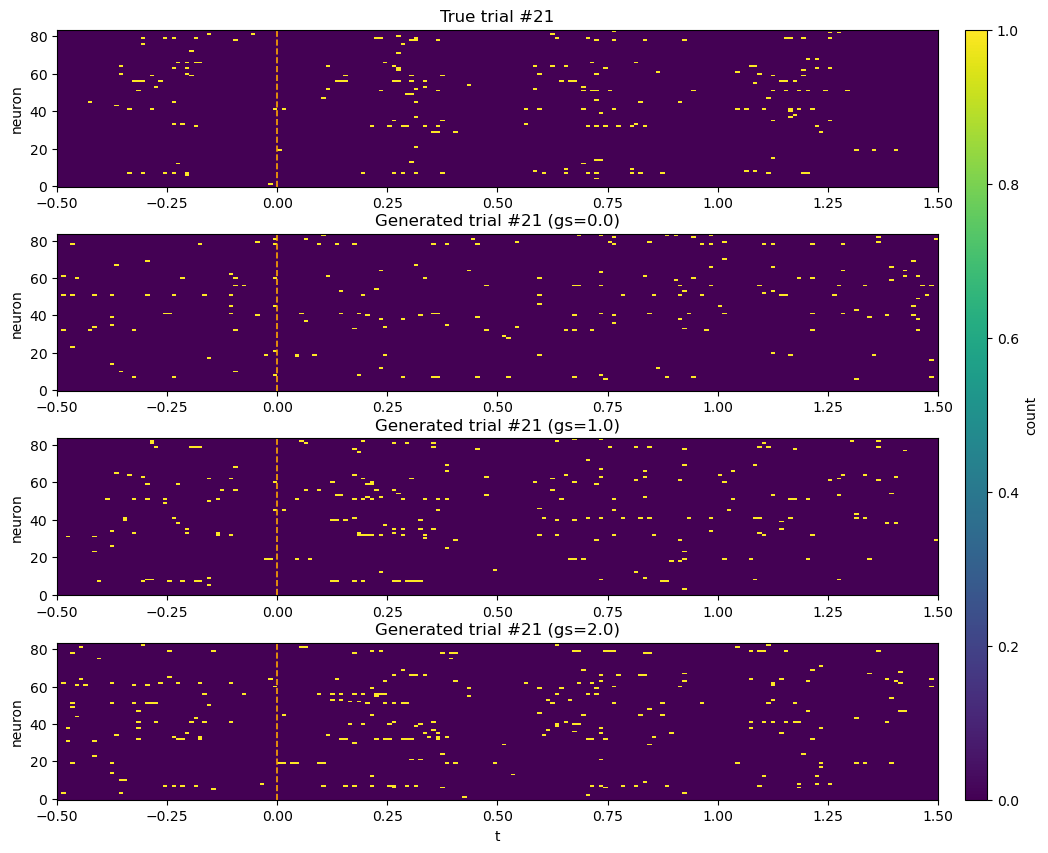

In [25]:
idx_use = int(va_trials[4])
# idx_use = int(tr_trials[13])

if idx_use not in GEN_CACHE["trial_row_bounds"]:
    raise ValueError("idx_use is not in the generated trial set.")

start, stop = GEN_CACHE["trial_row_bounds"][idx_use]
X_true_fig1 = GEN_CACHE["X_true_all"][start:stop]
t_fig1 = GEN_CACHE["trial_t_map"][idx_use]

X_gen_dict = {gs: GEN_CACHE["X_gen_all"][gs][start:stop] for gs in GEN_CACHE["guidance_scales"]}

all_vals = [X_true_fig1.ravel()] + [X_gen_dict[gs].ravel() for gs in GEN_CACHE["guidance_scales"]]
all_vals = np.concatenate(all_vals)
vmin = 0
vmax = max(1, np.percentile(all_vals, 99.5))

fig = plt.figure(figsize=(12, 10))
gspec = fig.add_gridspec(
    nrows=4,
    ncols=2,
    width_ratios=[40, 1],
    height_ratios=[1, 1, 1, 1],
    wspace=0.06,
    hspace=0.30,
)

ax0 = fig.add_subplot(gspec[0, 0])
ax1 = fig.add_subplot(gspec[1, 0], sharex=ax0, sharey=ax0)
ax2 = fig.add_subplot(gspec[2, 0], sharex=ax0, sharey=ax0)
ax3 = fig.add_subplot(gspec[3, 0], sharex=ax0, sharey=ax0)
cax = fig.add_subplot(gspec[:, 1])

im = _plot_heatmap(
    ax0,
    X_true_fig1,
    t_fig1,
    f"True trial #{idx_use}",
    vmin=vmin,
    vmax=vmax,
)

for ax, gs_val in zip([ax1, ax2, ax3], GEN_CACHE["guidance_scales"]):
    im = _plot_heatmap(
        ax,
        X_gen_dict[gs_val],
        t_fig1,
        f"Generated trial #{idx_use} (gs={gs_val})",
        vmin=vmin,
        vmax=vmax,
    )

ax3.set_xlabel("t")
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("count")
plt.show()

# Plot

In [26]:
import os

FIG_DIR = "figures_paper"
os.makedirs(FIG_DIR, exist_ok=True)

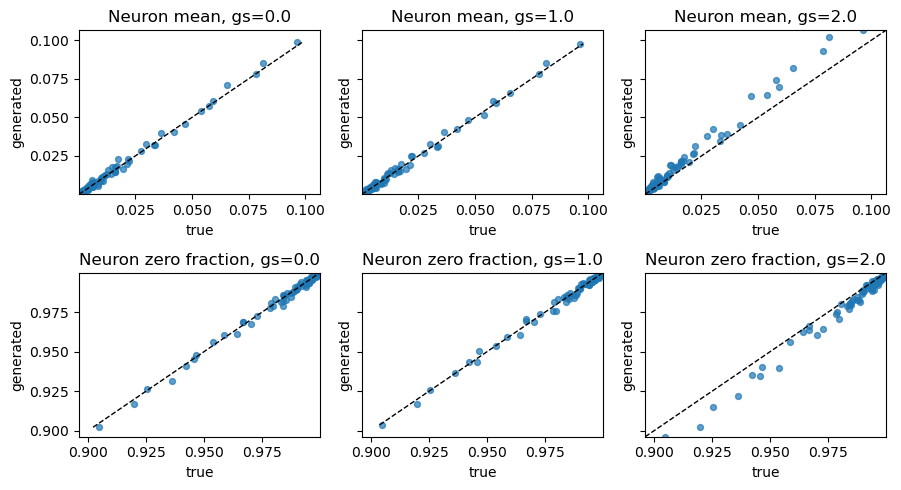

In [31]:
X_true_all = GEN_CACHE["X_true_all"]
X_gen_all = GEN_CACHE["X_gen_all"]
C_all = GEN_CACHE["C_all"]
guidance_scales = GEN_CACHE["guidance_scales"]

# 1. diagonal scatter: neuron mean and zero fraction, 2-by-3
fig, axes = plt.subplots(2, len(guidance_scales), figsize=(3 * len(guidance_scales), 5), sharex="row", sharey="row")

true_mean = X_true_all.mean(axis=0)
true_zero = (X_true_all == 0).mean(axis=0)

for k, gs in enumerate(guidance_scales):
    gen_mean = X_gen_all[gs].mean(axis=0)
    gen_zero = (X_gen_all[gs] == 0).mean(axis=0)

    ax = axes[0, k]
    ax.scatter(true_mean, gen_mean, alpha=0.7, s=18)
    lo = min(true_mean.min(), gen_mean.min())
    hi = max(true_mean.max(), gen_mean.max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1)
    ax.set_title(f"Neuron mean, gs={gs}")
    ax.set_xlabel("true")
    ax.set_ylabel("generated")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax = axes[1, k]
    ax.scatter(true_zero, gen_zero, alpha=0.7, s=18)
    lo = min(true_zero.min(), gen_zero.min())
    hi = max(true_zero.max(), gen_zero.max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1)
    ax.set_title(f"Neuron zero fraction, gs={gs}")
    ax.set_xlabel("true")
    ax.set_ylabel("generated")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

plt.tight_layout()
fig.savefig(
    os.path.join(FIG_DIR, "countFM_reg_diag_mean_zero_2x3.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

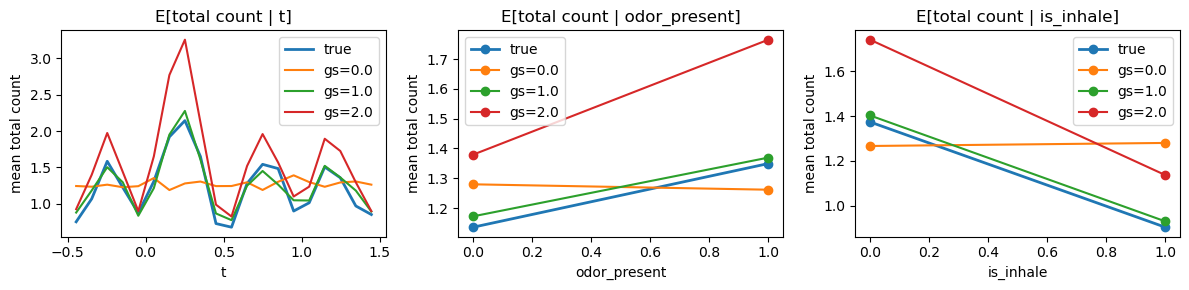

In [44]:
total_true = X_true_all.sum(axis=1)
total_gen = {gs: X_gen_all[gs].sum(axis=1) for gs in guidance_scales}

cov_t = np.asarray(C_all[:, C_columns.index("t")], dtype=float)
cov_odor_on = np.rint(C_all[:, C_columns.index("odor_present")]).astype(int)
cov_inhale = np.rint(C_all[:, C_columns.index("is_inhale")]).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

x_mid, y_true = _bin_conditional_mean(cov_t, total_true, nbins=20)
ax = axes[0]
ax.plot(x_mid, y_true, linewidth=2, label="true")
for gs in guidance_scales:
    _, y_gen = _bin_conditional_mean(cov_t, total_gen[gs], nbins=20)
    ax.plot(x_mid, y_gen, label=f"gs={gs}")
ax.set_title("E[total count | t]")
ax.set_xlabel("t")
ax.set_ylabel("mean total count")
ax.legend()

levels, y_true = _group_conditional_mean(cov_odor_on, total_true)
ax = axes[1]
ax.plot(levels, y_true, marker="o", linewidth=2, label="true")
for gs in guidance_scales:
    _, y_gen = _group_conditional_mean(cov_odor_on, total_gen[gs])
    ax.plot(levels, y_gen, marker="o", label=f"gs={gs}")
ax.set_title("E[total count | odor_present]")
ax.set_xlabel("odor_present")
ax.set_ylabel("mean total count")
ax.legend()

levels, y_true = _group_conditional_mean(cov_inhale, total_true)
ax = axes[2]
ax.plot(levels, y_true, marker="o", linewidth=2, label="true")
for gs in guidance_scales:
    _, y_gen = _group_conditional_mean(cov_inhale, total_gen[gs])
    ax.plot(levels, y_gen, marker="o", label=f"gs={gs}")
ax.set_title("E[total count | is_inhale]")
ax.set_xlabel("is_inhale")
ax.set_ylabel("mean total count")
ax.legend()

plt.tight_layout()
fig.savefig(
    os.path.join(FIG_DIR, "countFM_reg_cond_quality_t_odorpresent_inhale_1x3.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

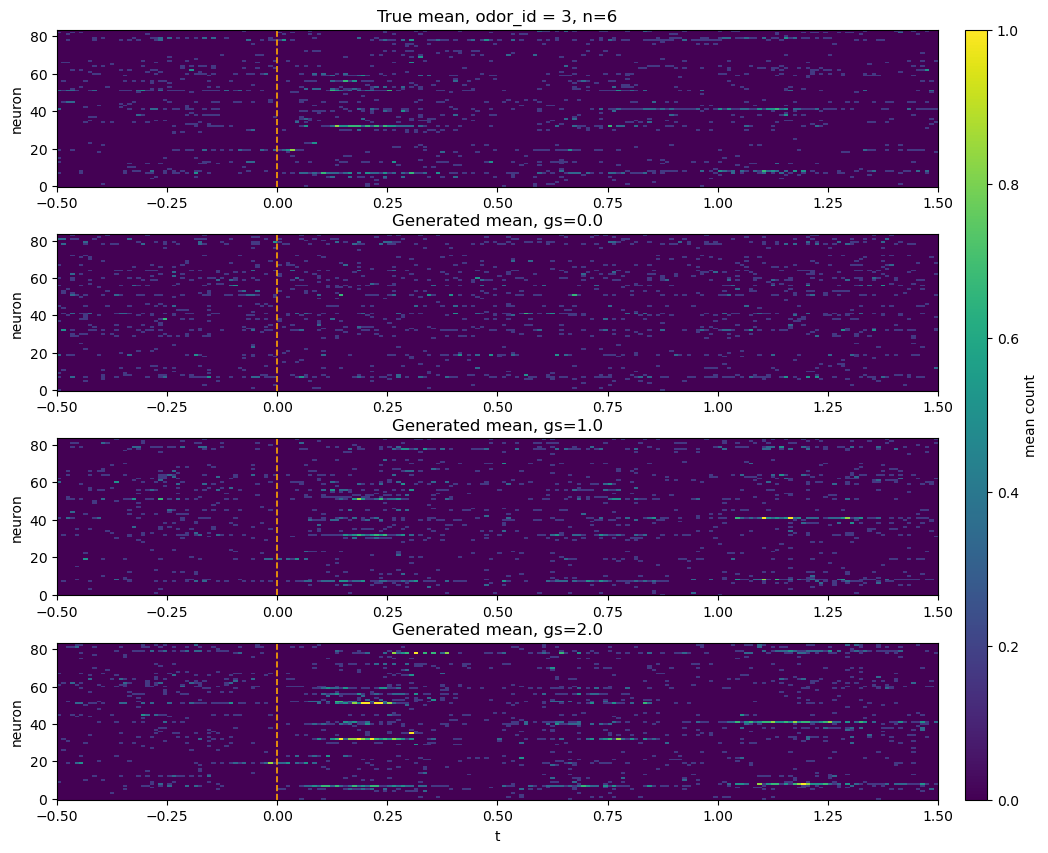

In [45]:
use_same_odor_only = True
odor_id_use = 3

trial_ids_all = GEN_CACHE["trial_ids"]

if use_same_odor_only:
    trial_ids_fig2 = np.array(
        [idx for idx in trial_ids_all if GEN_CACHE["trial_odor_map"][int(idx)] == odor_id_use],
        dtype=int,
    )
else:
    trial_ids_fig2 = trial_ids_all.copy()

if len(trial_ids_fig2) == 0:
    raise ValueError("No trials selected.")

X_true_trials = []
X_gen_trials = {gs: [] for gs in GEN_CACHE["guidance_scales"]}

for idx in trial_ids_fig2:
    start, stop = GEN_CACHE["trial_row_bounds"][int(idx)]
    X_true_trials.append(GEN_CACHE["X_true_all"][start:stop])
    for gs in GEN_CACHE["guidance_scales"]:
        X_gen_trials[gs].append(GEN_CACHE["X_gen_all"][gs][start:stop])

X_true_mean = np.stack(X_true_trials, axis=0).mean(axis=0)
X_gen_mean = {gs: np.stack(X_gen_trials[gs], axis=0).mean(axis=0) for gs in GEN_CACHE["guidance_scales"]}

t_fig2 = GEN_CACHE["trial_t_map"][int(trial_ids_fig2[0])]

all_vals = [X_true_mean.ravel()] + [X_gen_mean[gs].ravel() for gs in GEN_CACHE["guidance_scales"]]
all_vals = np.concatenate(all_vals)
vmin = 0
vmax = max(1, np.percentile(all_vals, 99.5))

fig = plt.figure(figsize=(12, 10))
gspec = fig.add_gridspec(
    nrows=4,
    ncols=2,
    width_ratios=[40, 1],
    height_ratios=[1, 1, 1, 1],
    wspace=0.06,
    hspace=0.30,
)

ax0 = fig.add_subplot(gspec[0, 0])
ax1 = fig.add_subplot(gspec[1, 0], sharex=ax0, sharey=ax0)
ax2 = fig.add_subplot(gspec[2, 0], sharex=ax0, sharey=ax0)
ax3 = fig.add_subplot(gspec[3, 0], sharex=ax0, sharey=ax0)
cax = fig.add_subplot(gspec[:, 1])

title_prefix = f"odor_id = {odor_id_use}" if use_same_odor_only else "all generated trials"

im = _plot_heatmap(
    ax0,
    X_true_mean,
    t_fig2,
    f"True mean, {title_prefix}, n={len(trial_ids_fig2)}",
    vmin=vmin,
    vmax=vmax,
)

for ax, gs_val in zip([ax1, ax2, ax3], GEN_CACHE["guidance_scales"]):
    im = _plot_heatmap(
        ax,
        X_gen_mean[gs_val],
        t_fig2,
        f"Generated mean, gs={gs_val}",
        vmin=vmin,
        vmax=vmax,
    )

ax3.set_xlabel("t")
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("mean count")

fig.savefig(
    os.path.join(FIG_DIR, f"countFM_reg_mean_heatmap_odor{odor_id_use}.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)